**NOTE:** As of 2/17/2023, there is a conflict on Google Colab between Scipy and Networkx. The following code cell will upgrade those libraries for the current session. You only need to run this once per starting up a Colab session for this notebook.

In [1]:
!pip install --upgrade scipy networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.2/25.2 MB 40.7 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.1
    Uninstalling scipy-1.15.1:
      Successfully uninstalled scipy-1.15.1

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import networkx as nx
import numpy as np

# Introduction

Imagine that you are tasked with engineering a scientific research tower on Mars.  The tower needs to house several research stations, labeled $0$, $1$, $2$, $3$ and $4$.  Your job is to determine where on the tower to attach each station, by selecting the numbers $h_0$, $h_1$, $h_2$, $h_3$ and $h_4$ specifying the stations' heights above the surface, measured from the surface to the base of the station.  (A negative $h_i$ is interpreted as underground.)  There are two requirements: station $0$ (the mining station) must be on the surface ($h_0=0$) and station $4$ (the atmospheric station) must be at height $1$ ($h_4=1$).



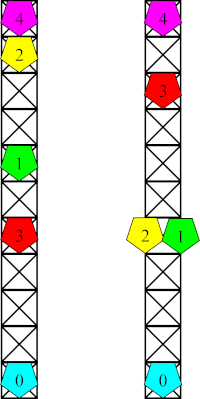



Your goal is to choose the station locations in order to minimize the daily operating cost of the research tower.  This cost depends on the station heights as follows.  As the tower operates, certain materials need to be transferred among the various stations; the cost of transferring material between two stations is proportional to the vertical distance between them.  Thus, for any pair of stations $i$ and $j$, there is an associated cost $\sigma_{ij}\big|h_i-h_j\big|$, where $\sigma_{ij}$ gives the cost of separating $i$ and $j$ by one unit of vertical distance.  The total cost of operating the tower each day is then given by the formula

$$
    \text{cost} = \sigma_{01}\big|h_0-h_1\big| + \sigma_{02}\big|h_0-h_2\big| + \sigma_{03}\big|h_0-h_3\big|
    + \cdots + \sigma_{34}\big|h_3-h_4\big|.
$$


The values of $\sigma_{ij}$ for this problem are summarized in the following table.

<pre>
+---++------+------+------+------+------+
|   ||   0  |   1  |   2  |   3  |   4  |
+===++======+======+======+======+======+
| 0 ||  --  |  0.8 |  0.7 |  0.0 |  0.4 |
+---++------+------+------+------+------+
| 1 ||  0.8 |  --  |  1.2 |  0.0 |  0.0 |
+---++------+------+------+------+------+
| 2 ||  0.7 |  1.2 |  --  |  0.5 |  0.0 |
+---++------+------+------+------+------+
| 3 ||  0.0 |  0.0 |  0.5 |  --  |  0.6 |
+---++------+------+------+------+------+
| 4 ||  0.4 |  0.0 |  0.0 |  0.6 |  --  |
+---++------+------+------+------+------+
</pre>

Notice, for example, that, since $\sigma_{03}=0$, there is no cost associated with separating stations $0$ and $3$ (presumably because no material needs to be transferred directly between them).  Also, notice that it is twice as expensive per unit distance to separate $1$ from $2$ as it is to separate $3$ from $4$.

The figure on the right shows two possible configurations.  (The horizontal crossbeams are separated by 0.1 units of distance.)  The first configuration has cost

$$
\begin{align*}
\text{cost} &= 0.8\cdot\big|h_0-h_1\big| +  0.7\cdot\big|h_0-h_2\big| +  0.4\cdot\big|h_0-h_4\big| +  1.2\cdot\big|h_1-h_2\big| +  0.5\cdot\big|h_2-h_3\big| +  0.6\cdot\big|h_3-h_4\big| \\
&= 0.8\cdot\big|0.0-0.6\big| +  0.7\cdot\big|0.0-0.9\big| +  0.4\cdot\big|0.0-1.0\big| +  1.2\cdot\big|0.6-0.9\big| +  0.5\cdot\big|0.9-0.4\big| +  0.6\cdot\big|0.4-1.0\big| = 2.48,
\end{align*}
$$

while the second has cost

$$
\begin{align*}
\text{cost} &= 0.8\cdot\big|h_0-h_1\big| +  0.7\cdot\big|h_0-h_2\big| +  0.4\cdot\big|h_0-h_4\big| +  1.2\cdot\big|h_1-h_2\big| +  0.5\cdot\big|h_2-h_3\big| +  0.6\cdot\big|h_3-h_4\big|\\
&= 0.8\cdot\big|0.0-0.4\big| +  0.7\cdot\big|0.0-0.4\big| +  0.4\cdot\big|0.0-1.0\big| +  1.2\cdot\big|0.4-0.4\big| +  0.5\cdot\big|0.4-0.8\big| +  0.6\cdot\big|0.8-1.0\big| = 1.32.
\end{align*}
$$

## Graph representation

More generally, suppose we have $n$ stations labeled $\{0,1,2,\ldots,n-1\}$.  The goal is to choose heights $\{h_0,h_1,h_2,\ldots,h_{n-1}\}$ to minimize the daily operating cost

$$
    \text{cost} = \sum_{0\le i<j\le n-1} \sigma_{ij}\big|h_i-h_j\big|,
$$

where $\sigma_{ij}$ gives the cost of separating stations $i$ and $j$ by one unit of height

We can represent this problem with a weighted undirected graph as follows.  Each station $\{0,1,2,\ldots,n-1\}$ is represented as a vertex.  For any pair of stations $i$ and $j$ such that $\sigma_{ij}>0$, we add an edge with weight $\sigma_{ij}$ between the corresponding nodes.  For this notebook, we'll assume the resulting graph is connected.  (As a challenge, you can prove that the general problem can be reduced to the connected case.)  Verify that the following graph represents the problem above.

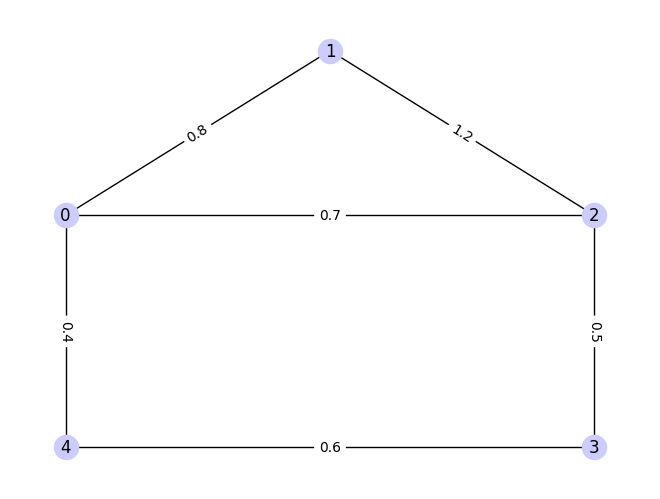

In [3]:
def draw_tower_graph(G,pos):
    """
    Draws a graph representing the tower problem.

    Args:
        G:   A NetworkX graph with 'sigma' values attached to each edge.
        pos: A position dictionary for plotting.

    Returns:
        Nothing
    """
    
    # fetch edge labels
    lbl = { (u,v):d['sigma'] for u,v,d in G.edges(data=True) }
    
    # draw the graph
    nx.draw(G,pos,with_labels=True,node_color='#ccccff')
    
    # label edges
    nx.draw_networkx_edge_labels(G,pos,edge_labels=lbl)


edges = [(0, 1, {'sigma': 0.8}), (1, 2, {'sigma': 1.2}), (2, 3, {'sigma': 0.5}),
         (3, 4, {'sigma': 0.6}), (4, 0, {'sigma': 0.4}), (0, 2, {'sigma': 0.7})]

pos = {0: (0, 0), 1: (0.5,0.71), 2: (1, 0), 3: (1, -1), 4: (0, -1)}

G = nx.Graph(edges)
draw_tower_graph(G,pos)

## A simple example

Before solving the original problem, let's see how to solve a simpler problem.

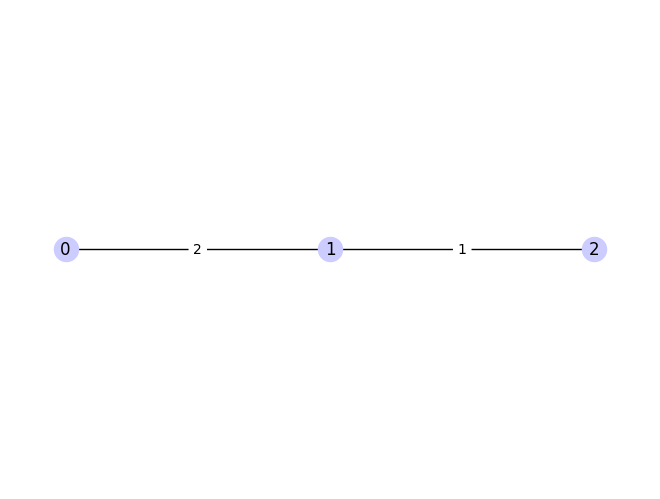

In [4]:
    

G2 = nx.Graph()
G2.add_edge(0,1,sigma=2)
G2.add_edge(1,2,sigma=1)
pos2 = {0:(0,0), 1:(1,0), 2:(2,0)}

draw_tower_graph(G2,pos2)

In this example, there is only one unknown quantity: $h_1$.  The tower cost, as a function of $h_1$, is

$$
    \text{cost} = 2\cdot\big|h_1-0\big| + 1\cdot\big|1-h_1\big|.
$$

First, notice that it would be silly to pick $h_1<0$.  Since we need to transfer material between $0$ and $1$ and between $1$ and $2$, what would be the point of putting station $1$ underground?  Similarly, it can't possibly be optimal to put $h_1>1$.  So, we can restrict our attention to $0\le h_1\le 1$.  Under these assumptions,

$$
    \text{cost} = 2(h_1-0) + (1-h_1) = h_1+1.
$$

This cost is minimized (subject to $0\le h_1\le 1$) when $h_1=0$.

This makes intuitive sense.  The two quantities of importance in the problem are the difference in height between $0$ and $1$ and the difference in height between $1$ and $2$.  It is twice as expensive per unit distance to separate $0$ from $1$ as it is to separate $1$ from $2$, so we should just put $0$ and $1$ on the same level.

Now let's get back to our more complicated example.

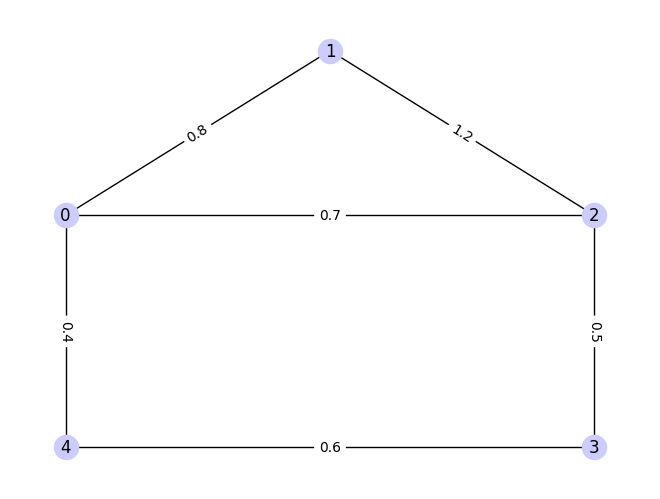

In [5]:
draw_tower_graph(G,pos)

# LP formulation

To recap, we have used a graph to represent the original tower problem.  We now have a weighted graph $G=(V,E,\sigma)$ with vertices $V$ representing the towers $0,1,\ldots,n-1$, with edges $E$ identifying the tower pairs $\{i,j\}$ between which material must be transferred, and with edge weights $\sigma_{ij}>0$ keeping track of the cost per unit distance of separating tower $i$ and $j$.  (Remember, we omit pairs from $E$ that would have $\sigma_{ij}=0$.)

In other words, so far we're just using the graph as a sort of "bookkeeping" tool to keep track of the relevant quantities.  It's going to turn out that this graph representation actually provides us with a very powerful way of expressing the solution, but, for now, just think of it as a way of encoding the problem.

## Writing the optimization problem

A good practice before solving a problem is to write it down in a familiar form.  Since we're trying to solve an optimization problem, let's write it down carefully, identifying the objective and constraints.  That will look something like this.

$$
\begin{align*}
    \underset{h}{\text{minimize}}\quad& \sum_{\{i,j\}\in E}\sigma_{ij}\big|h_i-h_j\big|\\
    \text{subject to}\quad & h_0 = 0,\;h_{n-1}=1
\end{align*}
$$

The objective is just another way of writing down the tower cost function from before.  (We're just excluding the pairs with $\sigma_{ij}=0$, which contribute nothing to the cost.)  There are only two constraints: the mining station is at height zero and the atmospheric station is at height 1.  (Notice the text $h$ beneath the word "minimize," indicating the optimization variables.  Often in optimization texts the optimization variables will not be shown explicitly, and you'll need to figure them out from context.)

## A standard transformation

If you work with optimization problems for a while, you'll start to develop a set of "tricks" for transforming optimization problems into certain standard forms.  One such standard form is the linear program (LP).  (You may want to review Section 4.3 of Boyd and Vandenberghe's [book](https://web.stanford.edu/~boyd/cvxbook/).)

In this case, the trick is to introduce a new variable $\rho_{ij}$ for each pair $\{i,j\}\in E$.  Intuitively, you should think of $\rho_{ij}$ as standing in for $\big|h_i-h_j\big|$, but we're not going to enforce that as a constraint.  Instead, we'll require something weaker: for each $\{i,j\}\in E$, we require that

$$
    \rho_{ij} \ge h_i-h_j \qquad\text{and}\qquad \rho_{ij} \ge h_j-h_i.
$$

Notice that this is equivalent to requiring that

$$
    \rho_{ij} \ge \max\{h_i-h_j,h_j-h_i\} = \big|h_i-h_j\big|.
$$

With that in mind, consider the following problem.

$$
\begin{align*}
    \underset{h,\rho}{\text{minimize}}\quad& \sum_{\{i,j\}\in E}\sigma_{ij}\rho_{ij}\\
    \text{subject to}\quad & h_0 = 0,\;h_{n-1}=1\\
    & \rho_{ij} \ge h_i - h_j\quad\forall\{i,j\}\in E\\
    & \rho_{ij} \ge h_j - h_i\quad\forall\{i,j\}\in E\\
\end{align*}
$$

Notice that we have added the optimization variables $\rho_{ij}$ to the original set of optimization variables $h_i$, and added some constraints on these variables.  In the original objective, where we had $\big|h_i-h_j\big|$, we have replaced it by $\rho_{ij}$.

It is straightforward to check that this is a linear program.  It's also clearly related to the original optimization problem above.  Proving that it is actually equivalent to the original takes a little thought, but it basically comes down to the following observation.  For each $\{i,j\}\in E$, $\sigma_{ij}>0$, so we are certainly interested in making $\rho_{ij}$ as small (or, rather, as close to $-\infty$) as we possibly can.  However, we clearly can't send $\rho_{ij}$ to $-\infty$ because we have to pick $h_i$, $h_j$ and $\rho_{ij}$ all together in a way that satisfies the constraints.  For whatever choice of $h_i$ and $h_j$ we make, the smallest we can make $\rho_{ij}$ is $\big|h_i-h_j\big|$, so that's what we'll end up choosing when we optimize.  The constraint $\rho_{ij}=\big|h_i-h_j\big|$ is called an *implicit constraint* because it is satisfied automatically by an optimal solution without needing to be enforced explicitly.

## Solving the LP

We'll start with a couple of functions that should look familiar.  (Compare to the Max Flow notebook.)  The idea, as before, is to enumerate the edge set $E$, and then treat $\sigma$ and $\rho$ as vectors, so that the objective above can be written as $\sigma^T\rho$.  For this problem, we have already assumed that the nodes are enumerated $0,1,\ldots,n-1$, so there is no need to do anything special with them.

In [6]:
def enumerate_edges(G):
    """
    Enumerates the edges of a graph.

    Args:
        G: The Networkx graph.

    Returns:
        Nothing.

    On exit, each edge of the graph G will have an attached property
    called 'enum' holding the index of that edge in G.edges().
    """
    
    for i,(u,v) in enumerate(G.edges()):
        G[u][v]['enum'] = i

def vectorize_sigma(G):
    """
    Computes the tower objective as a vector sigma.

    Args:
        G: The networkx graph.

    Returns:
        The objective vector.
        
    Each edge of the graph is assumed to have an attribute 'enum'
    giving its enumerated value and an attribute 'sigma' giving the
    cost per unit distance of separating the two nodes connected
    by the edge.
    """
    import numpy as np
    
    # initialize vector
    m = len(G.edges())
    sigma = np.zeros(m)
    
    # loop over edges
    for u,v,d in G.edges(data=True):
        
        # set sigma in the appropriate vector entry
        sigma[ d['enum'] ] = d['sigma']
        
    return sigma

enumerate_edges(G)
print('sigma = ', vectorize_sigma(G))

sigma =  [0.8 0.4 0.7 1.2 0.5 0.6]


### 💻 Exercise

Use cvxpy to complete the implementation of the ```solve_1``` function below. You need to define the constraints list `cons`.

In [17]:
def solve_1(G):
    """
    Solves the Mars tower problem as an LP.

    Args:
        G: The graph representation of the problem.

    Returns:
        c, h:
            - c is the optimal cost
            - h is a numpy array holding the solutuion h[i] = h_i

    On entry, each edge on the graph should have an attached attribute
    called 'sigma' giving the cost per unit distance of separating the
    two nodes connected by the edge.
    """
 
    import cvxpy as cvx
    import numpy as np

    # count edges and nodes
    m = len(G.edges())
    n = len(G.nodes())
    
    # enumerate the edges
    enumerate_edges(G)
    
    # find the objective vector
    sigma = vectorize_sigma(G)
    
    # set up optimization variables
    h   = cvx.Variable(n)
    rho = cvx.Variable(m)
    
    # YOUR CODE HERE
    cons = [h[0] == 0, h[n-1]==1]
    
    for u,v,d in G.edges(data=True):
        i = d['enum']
        cons.append(rho[i] >= h[u] - h[v])
        cons.append(rho[i] >= h[v] - h[u])
    
    # define the objective function
    obj = cvx.Minimize(sigma@rho)
    
    # set up and solve the problem
    prob = cvx.Problem(obj,cons)
    prob.solve(solver='SCS',eps=1e-8)
    
    # make sure we reached the optimum
    assert(prob.status=='optimal')
    
    # convert the solution to a numpy array and return
    return prob.value, np.array(h.value).flatten()

In [18]:
#########################################
# tests for solve_1

def test_solution(G,c,h):
    """
    Verifies that the tower configuration h has cost c.

    Args:
        G: The graph representation of the problem.
        c: The (alleged) cost.
        h: The tower configuration (as a numpy vector).

    Returns:
        Nothing.
        
    Raises an assertion error if the solution is infeasible or does not have
    cost c.
    """
    
    from numpy.testing import assert_almost_equal
    
    # check the "boundary conditions"
    assert_almost_equal(h[0],0)
    assert_almost_equal(h[-1],1)
    
    # compute the cost directly from the graph
    cost = 0.
    for i,j,d in G.edges(data=True):
        cost += d['sigma'] * abs( h[i] - h[j] )
        
    # check the cost
    assert_almost_equal(cost,c)
    
    
    
# set up test graphs

test_graphs = []
test_values = []

test_graphs.append( [(0,1,{'sigma':1.98}),(1,2,{'sigma':0.89}),(0,2,{'sigma':3.8})]  )
test_values.append(4.69)

test_graphs.append([(0, 1, {'sigma': 0.61}), (0, 2, {'sigma': 0.42}), (0, 4, {'sigma': 0.84}),
                    (1, 3, {'sigma': 0.62}), (1, 4, {'sigma': 0.39}), (2, 3, {'sigma': 0.64}),
                    (2, 4, {'sigma': 0.74}), (3, 4, {'sigma': 0.36})])
test_values.append(1.87)

test_graphs.append([(0, 5, {'sigma': 0.62}), (1, 5, {'sigma': 0.07}), (1, 6, {'sigma': 0.42}),
                    (2, 6, {'sigma': 0.61}), (3, 4, {'sigma': 0.22}), (3, 6, {'sigma': 0.87}), 
                    (4, 6, {'sigma': 0.62}), (5, 6, {'sigma': 0.02}), (5, 7, {'sigma': 0.88})])
test_values.append(0.62)

test_graphs.append([(0, 11, {'sigma': 0.61}), (0, 9, {'sigma': 0.41}), (0, 3, {'sigma': 0.45}),
                    (1, 8, {'sigma': 0.33}), (2, 13, {'sigma': 0.6}), (2, 14, {'sigma': 0.58}),
                    (3, 8, {'sigma': 0.18}), (3, 11, {'sigma': 0.76}), (3, 5, {'sigma': 0.96}),
                    (3, 14, {'sigma': 0.24}), (4, 13, {'sigma': 0.17}), (4, 14, {'sigma': 0.49}),
                    (5, 11, {'sigma': 0.71}), (5, 12, {'sigma': 0.44}), (6, 10, {'sigma': 0.44}),
                    (7, 8, {'sigma': 0.01}), (7, 10, {'sigma': 0.61}), (8, 9, {'sigma': 0.25}),
                    (8, 13, {'sigma': 0.52}), (9, 12, {'sigma': 0.45}), (10, 12, {'sigma': 0.07}),
                    (10, 14, {'sigma': 0.12}), (11, 12, {'sigma': 0.21}), (11, 14, {'sigma': 0.86}),
                    (12, 13, {'sigma': 0.41})])
test_values.append(1.47)


# testing function
def test_solver(solver):
    
    from numpy.testing import assert_almost_equal

    for i in range(len(test_graphs)):

        # create the graph
        G_test = nx.Graph(test_graphs[i])

        n = len(G_test.nodes())

        # solve the problem
        c,h = solver(G_test)

        # make sure value matches h
        test_solution(G_test,c,h)

        # make sure value is the true optimal value
        assert_almost_equal(c,test_values[i])
    
test_solver(solve_1)
print('All tests passed.')

All tests passed.


And here's the solution we were looking for.  Notice that, due to roundoff errors in the LP solver, the constraints on ```h[0]``` and ```h[4]``` might not hold exactly, but they should be close.

In [19]:
def describe_tower_solution(c,h):
    """
    Describes a solution to the tower problem.

    Args:
        c: The optimal cost.
        h: The optimal tower height arrangement.

    Returns:
        Nothing.  Just prints a description of the solution in English.
    """

    print('optimal cost    = {:.3f}'.format(c))
    print('optimal heights:')
    for i in range(len(h)):
        print('  station {} at height {:.3f}'.format(i,h[i]))
        

c,h = solve_1(G)
describe_tower_solution(c,h)

optimal cost    = 0.900
optimal heights:
  station 0 at height -0.000
  station 1 at height -0.000
  station 2 at height -0.000
  station 3 at height 1.000
  station 4 at height 1.000


# A network theory interpretation

If you examine the solution above for a few seconds, you'll notice an interesting fact.  In both of the examples we've worked so far, the optimal solution has all stations placed either at height 0 or height 1.  If you've studied LP problems before, this might not be too surprising; it's not uncommon in such problems for variables to take on extreme values.

But let's take a closer look at what's happening by visualizing the solution on the graph.  The function below draws the tower problem graph as before, but with some small modifications.  The edges are still labeled with the cost per unit height difference, but now nodes are labeled with their optimal height.  (Nodes $0$ and $n-1$ are distinguished by a larger size and different color.)  Moreover, the function highlights all edges (in red) where there is an appreciable difference in height between the stations on either end of the edge.  (By requiring that ```abs(h[v]-h[u]) > 1e-3```, we seek to ignore differences in height that are due merely to approximation errors in the numerical solution.)

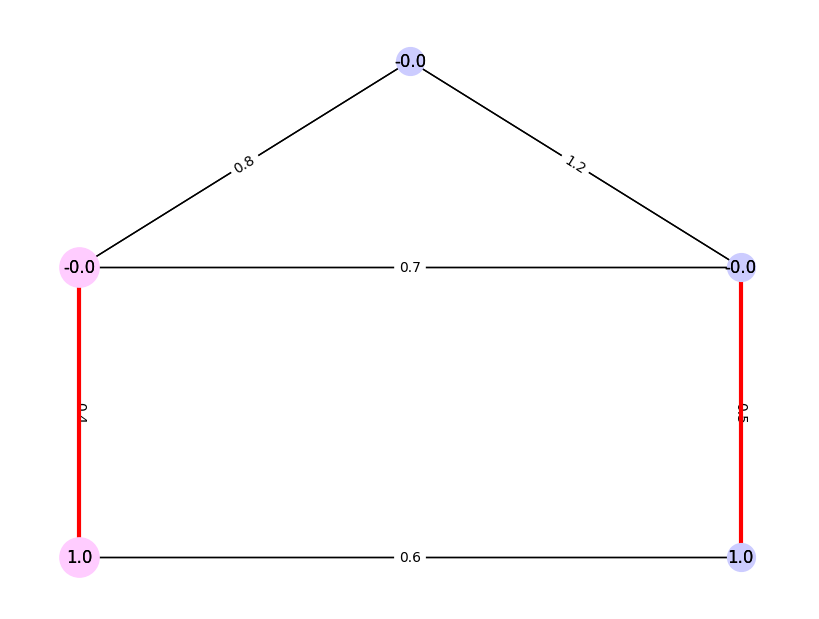

In [20]:
def draw_tower_solution(G,pos,h):
    """
    Visualizes a solution to the tower problem on a graph

    Args:
        G:   The graph representation of the problem.
        pos: Position dictionary for plotting.
        h:   The optimal tower height arrangement.

    Returns:
        Nothing.
    """
    
    import matplotlib.pyplot as plt
    import networkx as nx
    
    # number of nodes
    n = len(G.nodes())
    
    plt.figure(figsize=(8,6))
    
    # fetch node labels
    lbl = { v:round(h[v],2) for v in G.nodes()  }
    
    # draw the graph
    nx.draw(G,pos,labels=lbl,node_color='#ccccff',node_size=400)
    
    # hilight end nodes
    nx.draw(G,pos,labels=lbl,nodelist=[0,n-1],node_color='#ffccff',node_size=800)
    
    # fetch edge labels
    lbl = { (u,v):d['sigma'] for u,v,d in G.edges(data=True) }
    
    # draw all edges
    nx.draw_networkx_edge_labels(G,pos,edge_labels=lbl)
    
    # hilight special edges
    hilight = [(u,v) for u,v in G.edges() if abs(h[v]-h[u]) > 1e-3 ]
    nx.draw_networkx_edges(G,pos,edgelist=hilight,edge_color='red',width=3)

draw_tower_solution(G,pos,h)

Notice anything interesting?  Let's try another couple of examples.

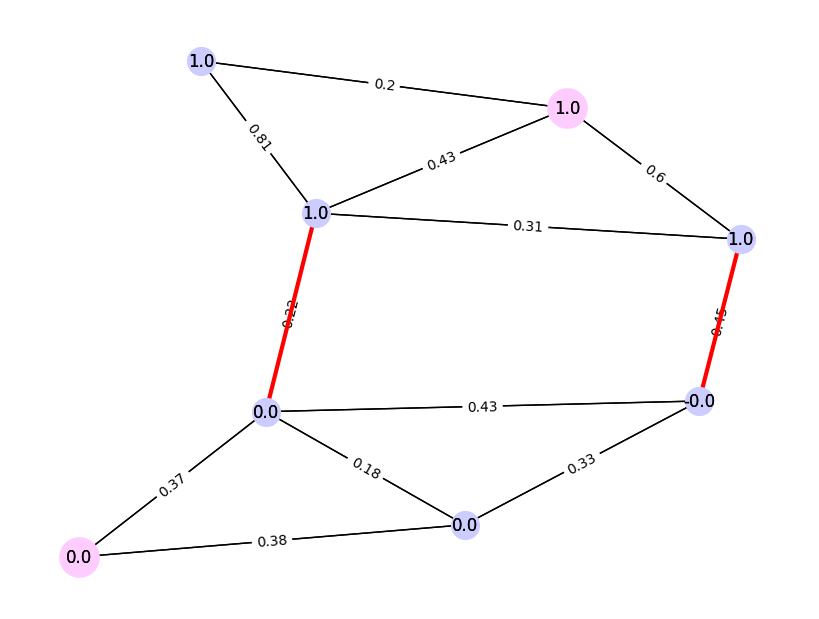

In [21]:
e2 = [(0, 1, {'enum': 0, 'sigma': 0.38}),  (0, 3, {'enum': 2, 'sigma': 0.37}), (1, 2, {'enum': 3, 'sigma': 0.33}), 
      (1, 3, {'enum': 4, 'sigma': 0.18}), (2, 3, {'enum': 5, 'sigma': 0.43}), (2, 5, {'enum': 6, 'sigma': 0.45}), 
      (3, 4, {'enum': 7, 'sigma': 0.22}), (4, 5, {'enum': 8, 'sigma': 0.31}), (4, 6, {'enum': 9, 'sigma': 0.81}), 
      (4, 7, {'enum': 10, 'sigma': 0.43}), (5, 7, {'enum': 12, 'sigma': 0.6}), (6, 7, {'enum': 13, 'sigma': 0.2})]

G2 = nx.Graph(e2)
pos2 = nx.spring_layout(G2)

c,h = solve_1(G2)
draw_tower_solution(G2,pos2,h)

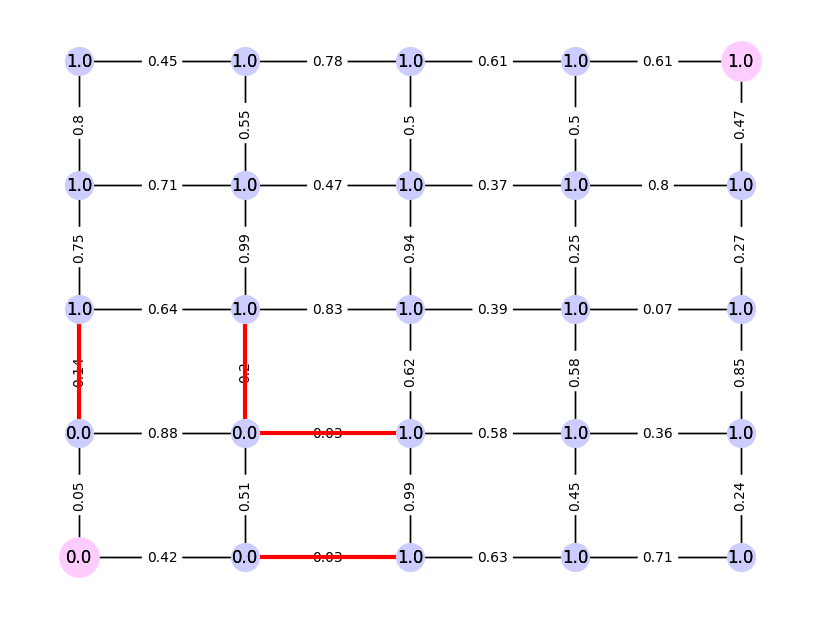

In [22]:
e3 = [(0, 1, {'enum': 0, 'sigma': 0.05}), (0, 5, {'enum': 1, 'sigma': 0.42}), (1, 2, {'enum': 2, 'sigma': 0.14}), 
      (1, 6, {'enum': 3, 'sigma': 0.88}), (2, 3, {'enum': 4, 'sigma': 0.75}), (2, 7, {'enum': 5, 'sigma': 0.64}), 
      (3, 8, {'enum': 6, 'sigma': 0.71}), (3, 4, {'enum': 7, 'sigma': 0.8}), (4, 9, {'enum': 8, 'sigma': 0.45}), 
      (5, 10, {'enum': 9, 'sigma': 0.03}), (5, 6, {'enum': 10, 'sigma': 0.51}), (6, 11, {'enum': 11, 'sigma': 0.03}), 
      (6, 7, {'enum': 12, 'sigma': 0.2}), (7, 8, {'enum': 13, 'sigma': 0.99}), (7, 12, {'enum': 14, 'sigma': 0.83}), 
      (8, 9, {'enum': 15, 'sigma': 0.55}), (8, 13, {'enum': 16, 'sigma': 0.47}), (9, 14, {'enum': 17, 'sigma': 0.78}), 
      (10, 11, {'enum': 18, 'sigma': 0.99}), (10, 15, {'enum': 19, 'sigma': 0.63}), (11, 16, {'enum': 20, 'sigma': 0.58}), 
      (11, 12, {'enum': 21, 'sigma': 0.62}), (12, 17, {'enum': 22, 'sigma': 0.39}), (12, 13, {'enum': 23, 'sigma': 0.94}), 
      (13, 18, {'enum': 24, 'sigma': 0.37}), (13, 14, {'enum': 25, 'sigma': 0.5}), (14, 19, {'enum': 26, 'sigma': 0.61}), 
      (15, 16, {'enum': 27, 'sigma': 0.45}), (15, 20, {'enum': 28, 'sigma': 0.71}), (16, 17, {'enum': 29, 'sigma': 0.58}), 
      (16, 21, {'enum': 30, 'sigma': 0.36}), (17, 18, {'enum': 31, 'sigma': 0.25}), (17, 22, {'enum': 32, 'sigma': 0.07}), 
      (18, 19, {'enum': 33, 'sigma': 0.5}), (18, 23, {'enum': 34, 'sigma': 0.8}), (19, 24, {'enum': 35, 'sigma': 0.61}), 
      (20, 21, {'enum': 36, 'sigma': 0.24}), (21, 22, {'enum': 37, 'sigma': 0.85}), (22, 23, {'enum': 38, 'sigma': 0.27}), 
      (23, 24, {'enum': 39, 'sigma': 0.47})]

pos3 = {0: (0, 0), 1: (0, 1), 2: (0, 2), 3: (0, 3), 4: (0, 4), 5: (1, 0), 6: (1, 1), 7: (1, 2), 8: (1, 3), 9: (1, 4), 
        10: (2, 0), 11: (2, 1), 12: (2, 2), 13: (2, 3), 14: (2, 4), 15: (3, 0), 16: (3, 1), 17: (3, 2), 18: (3, 3), 
        19: (3, 4), 20: (4, 0), 21: (4, 1), 22: (4, 2), 23: (4, 3), 24: (4, 4)}

G3 = nx.Graph(e3)
c,h = solve_1(G3)
draw_tower_solution(G3,pos3,h)

## Another solver

If you haven't guessed yet, here's the amazing fact.  (We won't prove it in this notebook, but you should go back over the previous examples and check.)  **The tower problem can be solved by a min-cut algorithm!**  (You may want to review max-flow min-cut notation.)

The algorithm goes like this.  

1. Let $s=0$ and $t=n-1$.
1. Find a minimum $st$-cut of $G$ (with the weights $\sigma_{ij}$ treated as capacities).  This provides a partition $V=S\cup T$ with $s\in S$ and $t\in T$.
1. Assign the heights as follows:
$$
    h_i =
    \begin{cases}
        0 & \text{if }i\in S\\
        1 & \text{if }i\in T
    \end{cases}
$$
1. This choice of heights is a solution of the tower problem.  Moreover, the optimal cost of the tower problem equals the capacity of the cut.

### 💻 Exercise

Complete the implementation of the following solver for the tower problem, based on the ```minimum_cut``` implementation provided by NetworkX.

In [23]:
def solve_2(G):
    """
    Solves the Mars tower problem via minimum cut.

    Args:
        G: The graph representation of the problem.

    Returns:
        c, h:
            - c is the optimal cost
            - h is a numpy array holding the solutuion h[i] = h_i

    On entry, each edge on the graph should have an attached attribute
    called 'sigma' giving the cost per unit distance of separating the
    two nodes connected by the edge.
    """
    import networkx as nx
    import numpy as np
    
    # count number of nodes
    n = len(G.nodes())
    
    # initialize heights
    h = np.zeros(n)
    
    # YOUR CODE HERE
    cut_value, (reachable, non_reachable) = nx.minimum_cut(G, 0, n-1, capacity='sigma')
    for i in reachable:
        h[i] = 0
    for i in non_reachable:
        h[i] = 1
    return cut_value, h

In [24]:
# run the tests
test_solver(solve_2)    
print('All tests passed.')

All tests passed.


## Taking stock

It's worth spending a little time reflecting on what just happened.  We started with a particular optimization problem (choosing the heights of stations on a research tower), found a way to express it as an LP, and then solved it.  We could have stopped there but, for no particular reason (other than the fact that we're involved in a class with the word "networks" in the title), we decided to visualize the problem and its solution on a graph.  Almost magically, it turned out that the problem we were trying to solve was equivalent to the min-cut problem, one of the most famous and widely studied problems in network theory.  (We won't prove the equivalence in this notebook, but it's true.)

If nothing else, this example illustrates one of the most powerful strategies in an applied math "toolbox": translating your problem into a known problem.  To get good at this, you need to 
1. Know what problems are out there that have good solution algorithms.  (This includes problems that don't have an immediately obvious connection to your problem.)
1. Know how to translate problems into other problems.

The first point requires reading broadly.  The second requires creative thinking and lots of trial-and-error.  The authors of this notebook noticed the connection between the tower problem and the min-cut problem from looking at graph plots like those above.  The proof of this connection took some time (and several failed attempts).

# A path formulation

To round out this notebook, let's do one more reformulation of the original tower problem.  The reasoning behind this transformation probably won't be obvious (it's based on some ideas arising from complex analysis and analysis on metric spaces).  Moreover, it might even seem like a step backward, since we're going to replace a relatively small number of constraints with a set of constraints that is generally much larger (at least for large graphs).

On the other hand, this is exactly the formulation that leads to a proof of equivalence between the tower problem and the min-cut problem.  Rather than think about that proof right now, let's just see how the path formulation works.

## Paths and their lengths

A *walk* in a graph $G=(V,E)$ is basically just a traversal (i.e., moving among nodes along edges in the graph).  We can represent a walk as a sequence of vertices $v_1v_2v_3\cdots v_k$ ($k$ is an arbitrary natural number), indicating which vertices are visited in what order.  For this to be a walk in $G$, each $v_i$ must be a vertex and every sequential pair $\{v_i,v_{i+1}\}$ must be an edge.  A *path* (or *simple path*) is just a walk that doesn't visit any vertex more than once (i.e., a path can't "loop back" on itself).

If each edge $\{i,j\}\in E$ has a *length* $\rho_{ij}$, then we can define the length of a path naturally.  To avoid subscripts within subscripts, let's adopt the notation that $\rho(i,j)$ is equivalent to $\rho_{ij}$.  Suppose $\gamma$ is a path; that is, $\gamma=v_1v_2\cdots v_k$.  Then we define the $\rho$*-length* of $\gamma$ as

$$
    \ell_\rho(\gamma) = \rho(v_1,v_2) + \rho(v_2,v_3) + \cdots + \rho(v_{k-1},v_k) = \sum_{i=1}^{k-1}\rho(v_i,v_{i+1}).
$$

In words, the $\rho$-length of a path is just the sum of the $\rho$-lengths of the edges it crosses.

## From $h$ to $\rho$

The notation $\rho$ above is not accidental.  Every choice of heights $h$ (called a *vertex potential*) in the tower problem gives us a $\rho$ by which to measure lengths: $\rho_{ij}=\big|h_i-h_j\big|$.  Suppose that we have chosen a set of heights $h$ that satisfy the tower problem constraints ($h_0=0, h_{n-1}=1$), and define $\rho$ from that choice.  Let's denote the family of all paths $\gamma$ starting at node $0$ and ending at node $n-1$ as $\Gamma$.  So every $\gamma\in\Gamma$ is a path of the form $\gamma=v_1v_2\cdots v_k$ with $v_1=0$ and $v_k=n-1$.  What do we know about the $\rho$-length of such a $\gamma$?

Using the property of absolute value that $|x|\ge -x$, we can write that

$$
\begin{split}
    \ell_\rho(\gamma) &= \rho(0,v_2) + \rho(v_2,v_3) + \rho(v_3,v_4) + \cdots + \rho(v_{k-1},n-1)\\
    &= \big|0-h_2\big| + \big|h_2-h_3\big| + \big|h_3-h_4\big| + \cdots + \big|h_{k-1}-1\big|\\
    &\ge -0 + h_2 - h_2 + h_3 - h_3 + h_4 \cdots - h_{k-1} + 1\\
    &\ge -0 + (h_2 - h_2) + (h_3 - h_3) + (h_4 -h_4) \cdots + (h_{k-1} - h_{k-1}) + 1 = 1.
\end{split}
$$

So, if the heights $h$ are admissible for the tower problem and $\rho$ is the corresponding edge length, then every path in $\Gamma$ must have length at least 1.

Now, suppose we write down the following problem.

$$
    \begin{align*}
    \underset{\rho}{\text{minimize}}\quad&\sum_{\{i,j\}\in E}\sigma_{ij}\rho_{ij}\\
    \text{subject to}\quad& \rho_{ij}\ge 0\;\forall\{i,j\}\in E\\
    & \ell_\rho(\gamma)\ge 1\;\forall\gamma\in\Gamma
    \end{align*}
$$

Is this equivalent to the tower problem?  Well, one inequality is evident.  If we make any feasible choice for the heights of the stations, $h$, then the corresponding $\rho$ as defined above is feasible for the new optimization problem.  Moreover, in this situation,

$$
    \rho_{ij} = \big|h_i-h_j\big|,\qquad\text{so},\qquad
    \sum_{\{i,j\}\in E}\sigma_{ij}\rho_{ij} = \sum_{\{i,j\}\in E}\sigma_{ij}\big|h_i-h_j\big|.
$$

That means that every value we can attain in the original tower problem can be attained in the new problem by just turning $h$ into $\rho$.  Thus, the value of the new problem is no larger than that of the tower problem.  In fact, the two problems are equivalent.  Rather than prove this, let's first solve the new optimization problem.  Then we'll see how we can transform from $\rho$ back to $h$ at the end.

## Solving the path problem

Although it might not be immediately evident, the path formulation is also an LP.  There are two types of constraints on the $\rho$ values.  First, there are non-negativity constraints; one for each edge.  Then, for each path in $\Gamma$ there is a path-length constraint.  These latter constraints are in some ways similar to the divergence-free constraints of the max-flow problem.  If we enumerate the edges in $E$, then every path $\gamma\in\Gamma$ can be represented as a vector, $v$, of zeros and ones (ones for the edges the path crosses, and zeros for the others).  If $\rho$ is also represented as a vector, then the corresponding length constraint is simply that $v^T\rho \ge 1$.  Now suppose we enumerate all paths in $\Gamma$: $\gamma_1,\gamma_2,\ldots,\gamma_r$.  Since each path gives a constraint, the entire family of paths $\Gamma$ gives $r$ constraints:

$$
    v_1^T\rho \ge 1,\quad v_2^T\rho\ge 1,\quad\ldots\quad v_r^T\rho \ge 1.
$$

If we store the vectors $v_i$ as rows of a matrix,

$$
    \mathcal{N} =
    \begin{bmatrix}
    v_1^T\\v_2^T\\\vdots\\v_r^T
    \end{bmatrix},
$$

then the path-length inequalities can be written as

$$
    \mathcal{N}\rho\ge\mathbf{1},
$$

where $\mathbf{1}$ is the vector of $r$ ones, and the inequality between vectors is interpreted element-by-element.

Thus, after enumerating the edges, the problem can be written in a more linear-algebraic form:

$$
    \begin{align*}
    \underset{\rho}{\text{minimize}}\quad&\sigma^T\rho\\
    \text{subject to}\quad& \rho\ge\mathbf{0}\\
    & \mathcal{N}\rho\ge\mathbf{1}
    \end{align*}
$$

which is clearly an LP problem.

Below is a function to solve the path formulation.

In [25]:
def solve_rho(G):
    """
    Solves the path formulation of the Mars tower.

    Args:
        G: The graph representation of the problem.

    Returns:
        c:   The optimal value of sigma^T rho.
        rho: A dictionary mapping each edge to its rho value.

    On entry, each edge on the graph should have an attached attribute
    called 'sigma' giving the cost per unit distance of separating the
    two nodes connected by the edge.
    """
    import networkx as nx
    import numpy as np
    import cvxpy as cvx
    
    # count number of nodes and edges
    n = len(G.nodes())
    m = len(G.edges())
    
    # enumerate the edges
    enumerate_edges(G)
    
    # set up optimization variables and objective
    rho   = cvx.Variable(m)
    sigma = vectorize_sigma(G)
    obj   = cvx.Minimize(sigma@rho)
    
    # get a list of all paths from 0 to n-1
    paths = list(nx.all_simple_paths(G,0,n-1))
    
    # count the number of paths
    r = len(paths)
    
    # initialize N matrix
    N = np.zeros((r,m))
    
    # add a row of N for each path
    for i,path in enumerate(paths):
        
        # loop over edges in the path
        for k in range(len(path)-1):
            
            # vertices for the edge
            u,v = path[k],path[k+1]
            
            # edge enumeration
            j = G[u][v]['enum']
            
            # update the row of N
            N[i,j] = 1
                
    # set up the constraints
    cons = [rho >= 0, N@rho >= 1]
    
    # set up and solve the problem
    prob = cvx.Problem(obj,cons)
    prob.solve(solver='SCS',eps=1e-8)
    
    # make sure we got an optimal solution
    assert(prob.status == 'optimal')
    
    # build the solution dictionary
    sol = {}
    for u,v,d in G.edges(data=True):
        sol[(u,v)] = rho[ d['enum'] ].value
    
    return prob.value,sol

As a quick check, let's compare the answers from ```solve_2``` and ```solve_rho```.  If everything is working correctly, the right two columns should match (approximately).

In [26]:
# solve using both methods
c,h   = solve_2(G)
_,rho = solve_rho(G)

# table header
print('| i | j |  h_i  |  h_j  | |h_i-h_j| | rho_ij |')
print('+---+---+-------+-------+-----------+--------+')

# print a row per edge
for u,v in G.edges():
    print('| {} | {} | {:.3f} | {:.3f} |   {:.3f}   | {: .3f} |'.format(u,v,h[u],h[v],abs(h[u]-h[v]),rho[(u,v)]))


| i | j |  h_i  |  h_j  | |h_i-h_j| | rho_ij |
+---+---+-------+-------+-----------+--------+
| 0 | 1 | 0.000 | 0.000 |   0.000   |  0.000 |
| 0 | 4 | 0.000 | 1.000 |   1.000   |  1.000 |
| 0 | 2 | 0.000 | 0.000 |   0.000   |  0.000 |
| 1 | 2 | 0.000 | 0.000 |   0.000   |  0.000 |
| 2 | 3 | 0.000 | 1.000 |   1.000   |  1.000 |
| 3 | 4 | 1.000 | 1.000 |   0.000   |  0.000 |


## From $\rho$ back to $h$

As promised, we'll now see how to get from $\rho$ back to the heights $h$ we're looking for.  The technique uses the concept of shortest-path distance, so let's discuss that first.

It will probably help if you imagine a network as a map of roads (the edges) cities (the vertices).  If there is a road between cities $i$ and $j$, then this road will have a length $\rho_{ij}$.  (This length doesn't have to be a "true" physical distance; depending on the application, for example, you may want to keep track of the amount of time required to drive from $i$ to $j$.  You can think of $\rho_{ij}$ as a measure of the amount of "effort" required to go from $i$ to $j$.)

Now, suppose you wish to travel from city $a$ to city $b$.  On most maps, you'll have many potential routes (paths) to choose from.  Let's call $\Gamma_{ab}$ the family of all such routes.  If you decide to take a particular route $\gamma\in\Gamma_{ab}$, the total distance you will travel is simply the accumulation of the distances of all roads you traverse.  Using the vocabulary above, the distance of $\gamma$ is $\ell_\rho(\gamma)$.

If someone were to ask you "How far is it from $a$ to $b$?" how would you find the answer?  The most natural answer is to identify the distance between $a$ and $b$ as the length of the *shortest* path from $a$ to $b$.  This is called the *shortest path distance* and is mathematically defined as

$$
    d_\rho(a,b) = \min_{\gamma\in\Gamma_{ab}}\ell_\rho(\gamma).
$$

The following video shows that when all edge weights, $\rho$, are positive, $d_\rho(a,b)$ really is a distance (i.e., metric) in the mathematical sense.

<center>
<table>
    <tr>
        <td>
            <a href="https://youtu.be/ybsJ_aT8j1o">
                <img src="https://img.youtube.com/vi/ybsJ_aT8j1o/hqdefault.jpg"><br>
                The shortest-path distance
            </a>
        </td>
    </tr>
</table>
</center>

If some edge weights are allowed to be zero (as is the case in the table above), $d_\rho(a,b)$ isn't truly a distance (some points have zero distance from each other).  However, it is sometimes still referred to as a distance or, more correctly, a degenerate distance.

So here's the amazing fact about the path formulation of the tower problem.  If $\rho^*$ is the optimal choice of $\rho$, then we can recover the optimal choice of heights $h^*$ by defining

$$
    h_i^* = d_{\rho^*}(0,i).
$$

Fortunately, there is a nice algorithm (called Dijkstra's algorithm) for finding the shortest-path distance in a graph.  And, since NetworkX has an implementation of this algorithm, we can convert $\rho$ to $h$ very simply.  The only caveat is that Dijkstra's algorithm only works when all edge lengths are non-negative.  In principle, that should be fine since we're requiring $\rho\ge\mathbf{0}$.  However, if you examine the $\rho$ that comes back from the ```solve_rho``` function, you'll see that sometimes it will contain small-magnitude negative numbers.  (Various roundoff errors in the optimization algorithm leave the constraints only *approximately* satisfied.)  So we'll need to round those values up to 0.  Here's the idea in action.

In [27]:
# solve using both methods
c,h   = solve_2(G)
_,rho = solve_rho(G)

# NetworkX needs a weight attached to each edge in order to perform shortest path searches
for u,v in G.edges():
    G[u][v]['rho'] = max( 0, rho[(u,v)] )  # the max here gets rid of small negatives

# table header
print('| i |  h_i  |  d(0,i) |')
print('+---+-------+---------+')

# loop over nodes
for u in G.nodes():
    
    # compute the distance from 0 to u using rho
    d = nx.shortest_path_length(G,0,u,'rho')
    
    # add a row to the table
    print('| {} | {:.3f} |  {:.3f}  |'.format(u,h[u],d))

| i |  h_i  |  d(0,i) |
+---+-------+---------+
| 0 | 0.000 |  0.000  |
| 1 | 0.000 |  0.000  |
| 2 | 0.000 |  0.000  |
| 3 | 1.000 |  1.000  |
| 4 | 1.000 |  1.000  |


### 💻 Exercise

Implement the function ```solve_3``` below, using the path formulation described above.  (You'll need to use NetworkX's shortest path length function.)

In [41]:
def solve_3(G):
    """
    Solves the Mars tower problem via the path formulation.

    Args:
        G: The graph representation of the problem.

    Returns:
        c, h:
            - c is the optimal cost
            - h is a numpy array holding the solutuion h[i] = h_i

    On entry, each edge on the graph should have an attached attribute
    called 'sigma' giving the cost per unit distance of separating the
    two nodes connected by the edge.
    """

    import networkx as nx
    import numpy as np
    h = np.zeros(len(G.nodes()))
    
    for i, u in enumerate(G.nodes()):
        h[i] = nx.shortest_path_length(G,0,u,'sigma')
        

    return min(h), h

In [42]:
# run the tests
test_solver(solve_3)


print('All tests passed.')

AssertionError: 
Arrays are not almost equal to 7 decimals
 ACTUAL: np.float64(2.87)
 DESIRED: 1

# Wrapping up

It may seem that we've gone to a lot of work to get a somewhat boring answer: every station in our tower should either be placed at ground level or at the top of the tower next to the atmospheric station.  All we're doing is figuring out which stations go in these two places.

However, in working through this problem, you've actually gotten a glimpse of something deeper: the tower problem is related to the min-cut problem.  Part of the "boringness" of the solution comes from the fact that the cost of separating two stations scales linearly with their relative distance.  It's easy to imagine a situation where this linear scaling is not a good model.  (Does it really only cost 1000 times as much to lift something 1 km as it costs to lift it 1 m?)  Suppose, instead, that we defined our cost function as

$$
    \text{cost} = \sum_{\{i,j\}\in E} \sigma_{ij}\big|h_i-h_j\big|^2.
$$

Here's what that would look like.

In [43]:
def solve_quad(G):
    """
    Solves the Mars tower problem with quadratic cost.

    Args:
        G: The graph representation of the problem.

    Returns:
        c, h:
            - c is the optimal cost
            - h is a numpy array holding the solutuion h[i] = h_i

    On entry, each edge on the graph should have an attached attribute
    called 'sigma' giving the cost per unit distance of separating the
    two nodes connected by the edge.
    """
 
    import cvxpy as cvx
    import numpy as np

    # count edges and nodes
    m = len(G.edges())
    n = len(G.nodes())
    
    # enumerate the edges
    enumerate_edges(G)
    
    # find the objective vector
    sigma = vectorize_sigma(G)
    
    # set up optimization variables
    h   = cvx.Variable(n)
    rho = cvx.Variable(m)
    
    # "boundary" conditions
    cons = [ h[0] == 0, h[n-1] == 1 ]
    
    # inequalties on rho
    for u,v,d in G.edges(data=True):
        i = d['enum']
        cons.append( rho[i] >= h[u]-h[v] )
        cons.append( rho[i] >= h[v]-h[u] )
    
    # define the objective function
    obj = cvx.Minimize(sigma@rho**2)
    
    # set up and solve the problem
    prob = cvx.Problem(obj,cons)
    prob.solve()
    
    # make sure we reached the optimum
    assert(prob.status=='optimal')
    
    # convert the solution to a numpy array and return
    return prob.value, np.array(h.value).flatten()

c,h = solve_quad(G)

print('optimal cost = {:.3f}'.format(c))
idx = np.argsort(h)[::-1]
for i in idx:
    print('  station {} at height {:.3f}'.format( i, h[i] ))

optimal cost = 0.622
  station 4 at height 1.000
  station 3 at height 0.631
  station 2 at height 0.188
  station 1 at height 0.113
  station 0 at height 0.000


Now the answer looks more interesting.  And, for those of you who remember effective resistance from Math 725, here's an interesting calculation we'll try to spend some time exploring later in the course.

In [44]:
# compute the weighted Laplacian for our graph
L = nx.laplacian_matrix(G,weight='sigma').todense()

# compute the "Green operator"
g = np.linalg.pinv(L)

# use the Green operator to compute the effective resistance from 0 to n-1=4
R_eff = g[0,0] + g[4,4] - 2*g[0,4]

# effective conductance is just 1/effective resistance
C_eff = 1./R_eff

# let's compare
print('optimal cost          = {:.6f}'.format(c))
print('effective conductance = {:.6f}'.format(C_eff))

optimal cost          = 0.621527
effective conductance = 0.621527


The linear tower problem is equivalent to min-cut.  The quadratic tower problem is equivalent to effective conductance!